In [1]:
from collections import OrderedDict
from zipfile import ZipFile
import random
import itertools

import torchvision
from torchvision import transforms
import torch


import numpy as np
import scipy
from scipy import linalg
import matplotlib.pyplot as plt
from tqdm import tqdm
import einops
from PIL import Image, ImageOps, ImageFilter


In [2]:
class Zip_ImageFolder(torchvision.datasets.ImageFolder):
    def __init__(self, zip_path, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.zip_path = zip_path
        self.zip_archvive = None

    def __getitem__(self, index: int):
        path, target = self.samples[index]
        if self.zip_archvive is None:
            self.zip_archvive = ZipFile(self.zip_path)

        path_split = path.split("/")
        fh = self.zip_archvive.open(
            path_split[-3] + "/" + path_split[-2] + "/" + path_split[-1]
        )

        image = Image.open(fh)
        sample = image.convert("RGB")

        if self.transform is not None:
            sample = self.transform(sample)

        if self.target_transform is not None:
            sample = self.target_transform(sample)

        return sample, target


In [3]:
class Solarization(object):
    def __init__(self, p):
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            return ImageOps.solarize(img)
        else:
            return img

class GaussianBlur(object):
    def __init__(self, p, min_sigma=0.1, max_sigma=2.0):
        self.p = p
        self.min_sigma = min_sigma
        self.max_sigma = max_sigma

    def __call__(self, img):
        if random.random() < self.p:
            sigma = random.random() * (self.max_sigma - self.min_sigma) + self.min_sigma 
            return img.filter(ImageFilter.GaussianBlur(sigma))
        else:
            return img

class Spatial_Photometric:
    def __init__(self, num_each=10, weak_transform=False):
        if not weak_transform:
            self.spatial_transform = transforms.Compose(
                [
                    transforms.RandomResizedCrop(224, interpolation=Image.BICUBIC),
                    transforms.RandomHorizontalFlip(p=0.5),
                ]
            )
            
            self.photometric_transform = transforms.Compose(
                [
                    transforms.RandomApply(
                        [
                            transforms.ColorJitter(
                                brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1
                            )
                        ],
                        p=0.8,
                    ),
                    transforms.RandomGrayscale(p=0.2),
                    GaussianBlur(p=0.1),
                    Solarization(p=0.2),
                ]
            )
        else:
            self.spatial_transform = transforms.Compose(
                [
                    transforms.RandomResizedCrop(224, scale=(0.16, 1.0), interpolation=Image.BICUBIC),
                    transforms.RandomHorizontalFlip(p=0.5),
                ]
            )
            
            self.photometric_transform = transforms.Compose(
                [
                    transforms.RandomApply(
                        [
                            transforms.ColorJitter(
                                brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05
                            )
                        ],
                        p=0.8,
                    ),
                    transforms.RandomGrayscale(p=0.2),
                    GaussianBlur(p=0.1, min_sigma=0.1, max_sigma=1.0),
                    Solarization(p=0.2),
                ]
            )

        self.normalization_transform = transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )
        self.num_each = num_each

    def __call__(self, x):
        crops = [self.spatial_transform(x) for _ in range(self.num_each)]
        crops_and_photometric = [
            [self.normalization_transform(self.photometric_transform(crop)) for _ in range(self.num_each)]
            for crop in crops
        ]

        imgs = [torch.stack(_) for _ in crops_and_photometric]
        imgs = torch.stack(imgs)

        return imgs

class Barlow_Transform:
    def __init__(self, n_transform):
        self.n_aug = n_transform
        self.transform = transforms.Compose(
            [
                transforms.RandomResizedCrop(224, interpolation=Image.BICUBIC),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomApply(
                    [
                        transforms.ColorJitter(
                            brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1
                        )
                    ],
                    p=0.8,
                ),
                transforms.RandomGrayscale(p=0.2),
                GaussianBlur(p=1.0),
                Solarization(p=0.0),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )
        self.transform_prime = transforms.Compose(
            [
                transforms.RandomResizedCrop(224, interpolation=Image.BICUBIC),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomApply(
                    [
                        transforms.ColorJitter(
                            brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1
                        )
                    ],
                    p=0.8,
                ),
                transforms.RandomGrayscale(p=0.2),
                GaussianBlur(p=0.1),
                Solarization(p=0.2),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )

    def __call__(self, x):
        y1 = self.transform(x)
        y = torch.zeros(self.n_aug, y1.shape[0], y1.shape[1], y1.shape[2])

        for i in range(self.n_aug // 2):
            y1 = self.transform(x)
            y2 = self.transform_prime(x)
            y[2 * i, :, :, :] = y1
            y[2 * i + 1, :, :, :] = y2
        return y

class ImageNetValTransform:
    def __init__(self):
        self.transform = transforms.Compose(
            [
                transforms.Resize(256),
                transforms.CenterCrop(224),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )

    def __call__(self, x):
        return self.transform(x)

In [4]:
imagenet_100_path = "/mnt/ceph/users/tyerxa/datasets/imagenet_100/"
n_transform=50
aug_test_data = Zip_ImageFolder(
                    zip_path=imagenet_100_path + "val.zip",
                    root=imagenet_100_path + "val/",
                    transform=Barlow_Transform(n_transform=n_transform)
)


num_each = 10
sp_test_data = Zip_ImageFolder(
                    zip_path=imagenet_100_path + "val.zip",
                    root=imagenet_100_path + "val/",
                    transform=Spatial_Photometric(num_each=num_each, weak_transform=False),
)

clean_test_data = Zip_ImageFolder(
                    zip_path=imagenet_100_path + "val.zip",
                    root=imagenet_100_path + "val/",
                    transform=ImageNetValTransform(),
)

In [14]:
batch = next(iter(sp_test_data))
batch[0].shape

torch.Size([10, 10, 3, 224, 224])

In [15]:
batch = next(iter(aug_test_data))
batch[0].shape

torch.Size([50, 3, 224, 224])

In [ ]:
bat

In [7]:
def extract_features_augmentation_manifold(model_1, model_2, loader, num_batches=None):
    if num_batches is None:
        num_batches = len(loader)

    features_1, features_2, labels = [], [], []
    n_ = 0
    for img_batch, label in tqdm(loader):
        img_batch = img_batch.cuda()
        b, n, c, h, w = img_batch.shape
        img_batch = einops.rearrange(img_batch, "b n c h w -> (b n) c h w")
        with torch.no_grad():
            outs_1 = model_1(img_batch)
            outs_2 = model_2(img_batch)

            outs_1 = einops.rearrange(outs_1, "(b n) c -> b n c", b=b, n=n)
            outs_2 = einops.rearrange(outs_2, "(b n) c -> b n c", b=b, n=n)

            features_1.append(outs_1.detach().cpu().numpy())
            features_2.append(outs_2.detach().cpu().numpy())
            labels.append(label.cpu().numpy())
        n_ += 1
        if n_ == num_batches:
            break


    features_1 = np.concatenate(features_1, axis=0)
    features_2 = np.concatenate(features_2, axis=0)
    labels = np.concatenate(labels, axis=0)

    return features_1, features_2, labels

def extract_features_spatial_photometric(model_1, model_2, loader, num_batches=None):
    if num_batches is None:
        num_batches = len(loader)
     
    features_1, features_2, labels = [], [], []
    n_ = 0
    for img_batch, label in tqdm(loader):
        with torch.no_grad():
            b, n, m, c, h, w = img_batch.shape
            img_batch = einops.rearrange(img_batch, 'b n m c h w -> (b n m) c h w')
            img_batch = img_batch.cuda()

            outs_1 = model_1(img_batch)
            outs_2 = model_2(img_batch)

            outs_1 = einops.rearrange(outs_1, '(b n m) c -> b n m c', b=b, n=n, m=m)
            outs_2 = einops.rearrange(outs_2, '(b n m) c -> b n m c', b=b, n=n, m=m)

            features_1.append(outs_1.detach().cpu().numpy())
            features_2.append(outs_2.detach().cpu().numpy())
            labels.append(label.numpy())

        n_ += 1
        if n_ == num_batches:
            break

    features_1 = np.concatenate(features_1)
    features_2 = np.concatenate(features_2)
    labels = np.concatenate(labels)

    return features_1, features_2, labels

In [8]:
def _load_composer_classifier_r50(sd):
    """
    Load a model saved via Composer into a vanilla torchvision model.
    """
    model = torchvision.models.resnet.resnet50()
    new_sd = OrderedDict()
    for k, v in sd.items():
        if 'lin_cls' in k:
            new_sd['fc.' + k.split('.')[-1]] = v
        if ".f." not in k:
            continue
        parts = k.split(".")
        idx = parts.index("f")
        new_k = ".".join(parts[idx + 1 :])
        new_sd[new_k] = v
    model.load_state_dict(new_sd, strict=True)
    return model.eval()

In [9]:
# Model Loading
path_model_invariant = '/mnt/ceph/users/tyerxa/equi_proj/training_checkpoints/final/resnet_50/MMCR/lmda_0.0/ep100-ba62500-rank0'
path_model_equivariant = '/mnt/ceph/users/tyerxa/equi_proj/training_checkpoints/final/resnet_50/MMCR/lmda_0.5/ep100-ba62500-rank0'

r50_invariant = torchvision.models.resnet50()
r50_equivariant = torchvision.models.resnet50()

sd_invariant = torch.load(path_model_invariant, map_location='cpu')["state"]["model"]
sd_equivariant = torch.load(path_model_equivariant, map_location='cpu')["state"]["model"]

r50_invariant = _load_composer_classifier_r50(sd_invariant)
r50_equivariant = _load_composer_classifier_r50(sd_equivariant)

# finally, lets remove the linear classifier 
r50_invariant.fc = torch.nn.Identity()
r50_equivariant.fc = torch.nn.Identity()

r50_invariant = r50_invariant.cuda().eval()
r50_equivariant = r50_equivariant.cuda().eval()

In [10]:
augmentation_loader = torch.utils.data.DataLoader(aug_test_data, batch_size=2, num_workers=6, shuffle=True)
spatialphotometric_loader = torch.utils.data.DataLoader(sp_test_data, batch_size=2, num_workers=6, shuffle=True)

In [11]:
features_1, features_2, labels = extract_features_augmentation_manifold(
    r50_invariant, 
    r50_equivariant, 
    augmentation_loader
)
centroids_1, centroids_2 = np.mean(features_1, axis=1), np.mean(features_2, axis=1)

features_1_sp, features_2_sp, labels_sp = extract_features_spatial_photometric(
    r50_invariant, 
    r50_equivariant, 
    spatialphotometric_loader
)

  0%|                                                                                                                                                   | 0/2500 [00:00<?, ?it/s]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉| 2499/2500 [07:06<00:00,  5.86it/s]


In [12]:
print(f'Augmentation manifold features shape: {features_1.shape}')
print(f'Spatial photometric features shape: {features_1_sp.shape}')
print(f'Augmentation manifold centroids shape: {centroids_1.shape}')

Augmentation manifold features shape: (5000, 50, 2048)
Spatial photometric features shape: (5000, 10, 10, 2048)
Augmentation manifold centroids shape: (5000, 2048)


In [13]:
def bures_metric(cov_1, cov_2, normalize_trace=True):
    """
    Compute the Bures distance between two covariance matrices

    Args:
        cov_1 (np.ndarray): First covariance matrix
        cov_2 (np.ndarray): Second covariance matrix
        normalize_trace (bool): Normalize the trace of the covariance matrices

    Returns:
        float: Bures distance
    """
    if normalize_trace:
        cov_1 = cov_1 / np.trace(cov_1)
        cov_2 = cov_2 / np.trace(cov_2)

    A = cov_1 + cov_2
    root_cov_2 = scipy.linalg.sqrtm(cov_2)
    B = root_cov_2 @ cov_1 @ root_cov_2
    B = scipy.linalg.sqrtm(B)

    return np.trace(A - 2 * B)

def compute_bures_distance_combos(features_1, features_2, labels, combos):
    dists_1, dists_2, labels_1, labels_2 = [], [], [], []
    for combo in combos:
        f_11, f_12 = features_1[combo[0]], features_1[combo[1]]
        f_21, f_22 = features_2[combo[0]], features_2[combo[1]]

        cov_11, cov_12 = np.cov(f_11.T), np.cov(f_12.T)
        cov_21, cov_22 = np.cov(f_21.T), np.cov(f_22.T)

        dist_1 = bures_metric(cov_11, cov_12)
        dist_2 = bures_metric(cov_21, cov_22)

        dists_1.append(dist_1)
        dists_2.append(dist_2)
        labels_1.append(labels[combo[0]])
        labels_2.append(labels[combo[1]])

    return dists_1, dists_2, labels_1, labels_2

def compute_bures_distance_sp(features_1, features_2, labels):
    dists_1, dists_2, labels_ = [], [], []
    for _ in range(labels.shape[0]):
        f_1, f_2 = features_1[_], features_2[_]

        sc1, pc1 = np.mean(f_1, axis=0), np.mean(f_1, axis=1)
        sc2, pc2 = np.mean(f_2, axis=0), np.mean(f_2, axis=1)

        cov_s1, cov_p1 = np.cov(sc1.T), np.cov(pc1.T)
        cov_s2, cov_p2 = np.cov(sc2.T), np.cov(pc2.T)

        dist_1 = bures_metric(cov_s1, cov_p1)
        dist_2 = bures_metric(cov_s2, cov_p2)

        dists_1.append(dist_1)
        dists_2.append(dist_2)
        labels_.append(labels[_])

    return dists_1, dists_2, labels_

def compute_bures_distance_centroids(features_1, features_2, centroids_1, centroids_2, labels):
    centroid_cov_1, centroid_cov_2 = np.cov(centroids_1.T), np.cov(centroids_2.T)

    dists_1, dists_2, labels_ = [], [], []
    for _ in range(features_1.shape[0]):
        f_1, f_2 = features_1[_], features_2[_]
        cov_1, cov_2 = np.cov(f_1.T), np.cov(f_2.T)

        dist_1 = bures_metric(centroid_cov_1, cov_1)
        dist_2 = bures_metric(centroid_cov_2, cov_2)

        dists_1.append(dist_1)
        dists_2.append(dist_2)
        labels_.append(labels[_])

    return dists_1, dists_2, labels_

In [14]:
combos_aug = itertools.combinations(range(features_1.shape[0]), 2)
combos_aug = list(combos_aug)
random.shuffle(combos_aug)

In [ ]:
chunk_size = 10
num_chunks = 500

centroid_distance_invariant = []
centroid_distance_equivariant = []

augmentation_distance_invariant = []
augmentation_distance_equivariant = []

sp_distance_invariant = []
sp_distance_equivariant = []
for i in range(num_chunks):
    print(f'Starting Chunk {i}')
    # aug-to-centroid chunk
    dists_1_centroid, dists_2_centroid, labels_centroid = compute_bures_distance_centroids(
        features_1[i*chunk_size:(i + 1)*chunk_size], 
        features_2[i*chunk_size:(i + 1)*chunk_size], 
        centroids_1,
        centroids_2,
        labels[i*chunk_size:(i + 1)*chunk_size]
    )

    # aug-to-aug chunk
    dists_1_aug, dists_2_aug, labels_1_aug, labels_2_aug = compute_bures_distance_combos(
        features_1,
        features_2,
        labels,
        combos_aug[i*chunk_size:(i + 1)*chunk_size]
    )

    # spatial-to-photometric chunk
    dists_1_sp, dists_2_sp, labels_sp_ = compute_bures_distance_sp(
        features_1_sp[i*chunk_size:(i + 1)*chunk_size],
        features_2_sp[i*chunk_size:(i + 1)*chunk_size],
        labels_sp[i*chunk_size:(i + 1)*chunk_size]
    )

    centroid_distance_invariant.append(dists_1_centroid)
    centroid_distance_equivariant.append(dists_2_centroid)
    augmentation_distance_invariant.append(dists_1_aug)
    augmentation_distance_equivariant.append(dists_2_aug)
    sp_distance_invariant.append(dists_1_sp)
    sp_distance_equivariant.append(dists_2_sp)

Starting Chunk 0


Starting Chunk 1
Starting Chunk 2
Starting Chunk 3
Starting Chunk 4
Starting Chunk 5
Starting Chunk 6
Starting Chunk 7
Starting Chunk 8
Starting Chunk 9
Starting Chunk 10
Starting Chunk 11
Starting Chunk 12
Starting Chunk 13
Starting Chunk 14
Starting Chunk 15
Starting Chunk 16
Starting Chunk 17
Starting Chunk 18
Starting Chunk 19
Starting Chunk 20
Starting Chunk 21
Starting Chunk 22
Starting Chunk 23
Starting Chunk 24
Starting Chunk 25
Starting Chunk 26
Starting Chunk 27


Augmentation Manifold: 0.4762464640057251
Centroid: -0.01587574070611497
Spatial Photometric: -0.026182533787253437


/mnt/home/tyerxa/miniconda3/envs/mmcr_clone/lib/python3.10/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


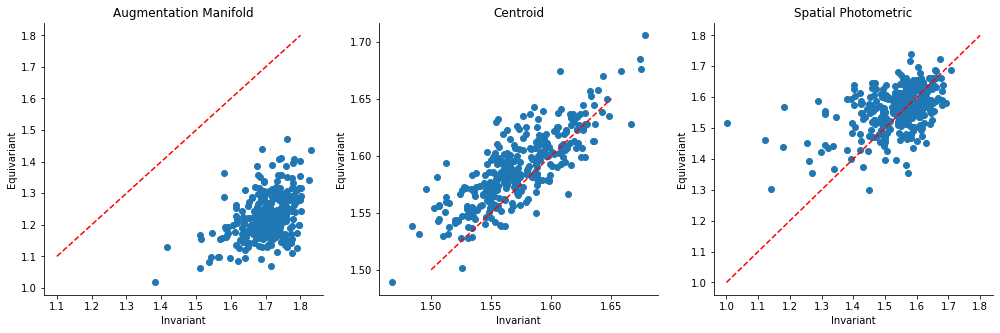

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(17, 5))

axs[0].scatter(
    np.concatenate(augmentation_distance_invariant),
    np.concatenate(augmentation_distance_equivariant),
)
axs[1].scatter(
    np.concatenate(centroid_distance_invariant),
    np.concatenate(centroid_distance_equivariant),
)
axs[2].scatter(
    np.concatenate(sp_distance_invariant),
    np.concatenate(sp_distance_equivariant),
)

axs[0].set_title("Augmentation Manifold")
axs[1].set_title("Centroid")
axs[2].set_title("Spatial Photometric")

axs[0].set_xlabel("Invariant")
axs[0].set_ylabel("Equivariant")
axs[1].set_xlabel("Invariant")
axs[1].set_ylabel("Equivariant")
axs[2].set_xlabel("Invariant")
axs[2].set_ylabel("Equivariant")

# turn off right/top spines
for ax in axs:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

axs[0].plot(
    np.linspace(1.1, 1.8, 100),
    np.linspace(1.1, 1.8, 100),
    color='red',
    linestyle='--',
)

axs[1].plot(
    np.linspace(1.5, 1.65, 100),
    np.linspace(1.5, 1.65, 100),
    color='red',
    linestyle='--',
)

axs[2].plot(
    np.linspace(1.0, 1.8, 100),
    np.linspace(1.0, 1.8, 100),
    color='red',
    linestyle='--',
)

delta_mean_aug = np.mean(np.concatenate(augmentation_distance_equivariant)) - np.mean(np.concatenate(augmentation_distance_invariant))
delta_mean_centroid = np.mean(np.concatenate(centroid_distance_equivariant)) - np.mean(np.concatenate(centroid_distance_invariant))
delta_mean_sp = np.mean(np.concatenate(sp_distance_equivariant)) - np.mean(np.concatenate(sp_distance_invariant))

print(f"Augmentation Manifold: {-1.0 * np.real(delta_mean_aug)}")
print(f"Centroid: {-1.0 * np.real(delta_mean_centroid)}")
print(f"Spatial Photometric: {-1.0 * np.real(delta_mean_sp)}")